<a href="https://colab.research.google.com/github/Sencer1/pytorch/blob/main/deneme334.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import jsbsim
import os
import numpy as np
import gymnasium as gym

In [2]:
class FlightEnv(gym.Env):

  def __init__(self):
    super().__init__()

    self.fdm = jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
    self.fdm.load_model("c172p")

    self.action_space = gym.spaces.Box(
        low=np.array([-1, -1, -1, 0]), # elevator, aileron, rudder, throttle
        high=np.array([1, 1, 1, 1]),
        dtype=np.float32
    )

    self.observation_space = gym.spaces.Box(
        low=-np.inf,
        high=np.inf,
        shape=(6,), # altitude, velocity, pitch, roll, yaw, vertical_speed
        dtype=np.float32
    )

  # reset episode başı için başlangıç durumlarını getirmek için
  def reset(self, seed=None, options=None):
    super().reset(seed=seed)

    self.fdm =jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
    self.fdm.load_model("c172p")

    self.fdm["ic/h-sl-ft"] = 5000 # yükselik
    self.fdm["ic/vc-kts"] = 120 # başlangıç hızı
    self.fdm["ic/terrain-elevation-ft"] = 0 #zemin yüksekliği

    self.fdm.run_ic()

    observation = self._get_observation()
    info = {}

    return observation, info

  # step(action) ileri götürmek için state'i
  # istediğimiz staleri ppo ya vermek için burası
  def _get_observation(self):

    altitude = self.fdm["position/h-sl-ft"]
    velocity = self.fdm["velocities/vtrue-kts"]
    pitch = self.fdm["attitude/theta-rad"]
    roll = self.fdm["attitude/phi-rad"]
    yaw = self.fdm["attitude/psi-rad"]
    vertical_speed = self.fdm["velocities/v-down-fps"]

    observation = np.array([
        altitude,
        velocity,
        pitch,
        roll,
        yaw,
        vertical_speed
    ])

    return observation

In [3]:
env = FlightEnv()

observation, info = env.reset()

print("Observation: ", observation)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [4]:
"""
step()
ppo action step(action) action ı jsbsim e gönderir jsbsim çlaışır yeni observation reward yeni döngü
"""

'\nstep()\nppo action step(action) action ı jsbsim e gönderir jsbsim çlaışır yeni observation reward yeni döngü\n'

In [5]:
class FlightEnv(gym.Env):

  def __init__(self):
    super().__init__()

    self.fdm = jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
    self.fdm.load_model("c172p")

    self.action_space = gym.spaces.Box(
        low=np.array([-1, -1, -1, 0]), # elevator, aileron, rudder, throttle
        high=np.array([1, 1, 1, 1]),
        dtype=np.float32
    )

    self.observation_space = gym.spaces.Box(
        low=-np.inf,
        high=np.inf,
        shape=(6,), # altitude, velocity, pitch, roll, yaw, vertical_speed
        dtype=np.float32
    )

  # reset episode başı için başlangıç durumlarını getirmek için
  def reset(self, seed=None, options=None):
    super().reset(seed=seed)

    self.fdm =jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
    self.fdm.load_model("c172p")

    self.fdm["ic/h-sl-ft"] = 5000 # yükselik
    self.fdm["ic/vc-kts"] = 120 # başlangıç hızı
    self.fdm["ic/terrain-elevation-ft"] = 0 #zemin yüksekliği

    self.fdm.run_ic()

    observation = self._get_observation()
    info = {}

    return observation, info

  # step(action) ileri götürmek için state'i
  # istediğimiz staleri ppo ya vermek için burası
  def _get_observation(self):

    altitude = self.fdm["position/h-sl-ft"]
    velocity = self.fdm["velocities/vtrue-kts"]
    pitch = self.fdm["attitude/theta-rad"]
    roll = self.fdm["attitude/phi-rad"]
    yaw = self.fdm["attitude/psi-rad"]
    vertical_speed = self.fdm["velocities/v-down-fps"]

    observation = np.array([
        altitude,
        velocity,
        pitch,
        roll,
        yaw,
        vertical_speed
    ])

    return observation

  def step(self, action):
    elevator = action[0]
    aileron = action[1]
    rudder = action[2]
    throttle = action[3]

    self.fdm["fcs/elevator-cmd-norm"] = float(elevator)
    self.fdm["fcs/aileron-cdm-norm"] = float(aileron)
    self.fdm["fcs/rudder-cmd-norm"] = float(rudder)
    self.fdm["fcs/throtlle-cmd-norm"] = float(throttle)

    # bir adım ileri götürmek için
    self.fdm.run()

    observation = self._get_observation()

    reward = 0.0

    terminated = False
    truncated = False

    info = {}

    return observation, reward, terminated, truncated, info


In [6]:
env = FlightEnv()

env.reset()

action = np.array([0.2, 0.0, 0.0, 0.8], dtype=np.float32)

observation, reward, terminated, truncated, info = env.step(action)

print("observation:", observation)
print("reward", reward)
print("termianted", terminated)
print("truncated", truncated)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [7]:
class FlightEnv(gym.Env):

  def __init__(self):
    super().__init__()

    self.fdm = jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
    self.fdm.load_model("c172p")

    self.action_space = gym.spaces.Box(
        low=np.array([-1, -1, -1, 0]), # elevator, aileron, rudder, throttle
        high=np.array([1, 1, 1, 1]),
        dtype=np.float32
    )

    self.observation_space = gym.spaces.Box(
        low=-np.inf,
        high=np.inf,
        shape=(6,), # altitude, velocity, pitch, roll, yaw, vertical_speed
        dtype=np.float32
    )

  # reset episode başı için başlangıç durumlarını getirmek için
  def reset(self, seed=None, options=None):
    super().reset(seed=seed)

    self.fdm =jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
    self.fdm.load_model("c172p")

    self.fdm["ic/h-sl-ft"] = 5000 # yükselik
    self.fdm["ic/vc-kts"] = 120 # başlangıç hızı
    self.fdm["ic/terrain-elevation-ft"] = 0 #zemin yüksekliği

    self.fdm.run_ic()

    observation = self._get_observation()
    info = {}

    return observation, info

  # step(action) ileri götürmek için state'i
  # istediğimiz staleri ppo ya vermek için burası
  def _get_observation(self):

    altitude = self.fdm["position/h-sl-ft"]
    velocity = self.fdm["velocities/vtrue-kts"]
    pitch = self.fdm["attitude/theta-rad"]
    roll = self.fdm["attitude/phi-rad"]
    yaw = self.fdm["attitude/psi-rad"]
    vertical_speed = self.fdm["velocities/v-down-fps"]

    observation = np.array([
        altitude,
        velocity,
        pitch,
        roll,
        yaw,
        vertical_speed
    ])

    return observation

  def step(self, action):
    elevator = action[0]
    aileron = action[1]
    rudder = action[2]
    throttle = action[3]

    self.fdm["fcs/elevator-cmd-norm"] = float(elevator)
    self.fdm["fcs/aileron-cdm-norm"] = float(aileron)
    self.fdm["fcs/rudder-cmd-norm"] = float(rudder)
    self.fdm["fcs/throtlle-cmd-norm"] = float(throttle)

    # bir adım ileri götürmek için
    self.fdm.run()

    observation = self._get_observation()

    target_pitch = 0.0
    pitch = self.fdm["attitude/theta-rad"]
    error = pitch - target_pitch
    reward = -abs(error)

    terminated = False
    truncated = False

    info = {}

    return observation, reward, terminated, truncated, info


In [8]:
env.reset()
action1 = np.array([0.0, 0.0, 0.0, 0.5], dtype=np.float32)
for i in range(1000):
  observation1, reward, terminated, truncated, info = env.step(action1)
env.reset()
action2 = np.array([0.5, 0.0, 0.0, 0.5], dtype=np.float32)
for i in range(1000):
  observation2, reward, terminated, truncated, info = env.step(action2)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [9]:
print(observation1)
print("-" * 60)
print(observation2)

[ 5.46097988e+03  4.81185475e+01  4.23105992e-01 -2.65335006e-01
  6.04925372e+00 -2.55861358e+01]
------------------------------------------------------------
[ 4.24604696e+03  1.58057684e+02 -8.05245084e-01  1.23056578e-02
  8.73712754e-03  1.81449429e+02]


In [10]:
class FlightEnv(gym.Env):

  def __init__(self):
    super().__init__()

    self.fdm = jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
    self.fdm.load_model("c172p")

    self.action_space = gym.spaces.Box(
        low=-1, # elevator, aileron, rudder, throttle
        high=1,
        shape=(4,),
        dtype=np.float32
    )

    self.observation_space = gym.spaces.Box(
        low=-np.inf,
        high=np.inf,
        shape=(6,), # altitude, velocity, pitch, roll, yaw, vertical_speed
        dtype=np.float32
    )

    self.step_count = 0
    self.max_steps = 500

  # reset episode başı için başlangıç durumlarını getirmek için
  def reset(self, seed=None, options=None):
    super().reset(seed=seed)

    self.step_count = 0

    self.fdm =jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
    self.fdm.load_model("c172p")

    self.fdm["ic/h-sl-ft"] = 5000 # yükselik
    self.fdm["ic/vc-kts"] = 120 # başlangıç hızı
    self.fdm["ic/terrain-elevation-ft"] = 0 #zemin yüksekliği

    self.fdm.run_ic()

    observation = self._get_observation()
    info = {}

    return observation, info

  # step(action) ileri götürmek için state'i
  # istediğimiz staleri ppo ya vermek için burası
  def _get_observation(self):

    altitude = self.fdm["position/h-sl-ft"]
    velocity = self.fdm["velocities/vtrue-kts"]
    pitch = self.fdm["attitude/theta-rad"]
    roll = self.fdm["attitude/phi-rad"]
    yaw = self.fdm["attitude/psi-rad"]
    vertical_speed = self.fdm["velocities/v-down-fps"]

    observation = np.array([
        altitude,
        velocity,
        pitch,
        roll,
        yaw,
        vertical_speed
    ], dtype=np.float32)

    return observation

  def step(self, action):
    elevator = action[0]
    aileron = action[1]
    rudder = action[2]
    throttle = (action[3] + 1) / 2

    self.fdm["fcs/elevator-cmd-norm"] = float(elevator)
    self.fdm["fcs/aileron-cdm-norm"] = float(aileron)
    self.fdm["fcs/rudder-cmd-norm"] = float(rudder)
    self.fdm["fcs/throtlle-cmd-norm"] = float(throttle)

    # bir adım ileri götürmek için
    self.fdm.run()

    self.step_count += 1

    observation = self._get_observation()

    target_pitch = 0.0
    pitch = self.fdm["attitude/theta-rad"]
    error = pitch - target_pitch
    reward = -abs(error)

    terminated = False
    truncated = self.step_count >= self.max_steps

    info = {}

    return observation, reward, terminated, truncated, info


In [11]:
env = FlightEnv()

observation, info = env.reset()
for i in range(505):
  action = env.action_space.sample() # örnek bir action oluşturur rastgele
  observation, reward, terminated, truncated, info = env.step(action)

  if truncated:
    print("Episode bitti")
    print("step: ", i)
    break




     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

    Function: aero/function/qbar-induced-psf

  Aerodynamics (Lift|Side|Drag axes):

    Function: aero/coefficient/CDo
    1 dimensional table with 4 rows.
	0	0	
	10	0.007	
	20	0.012	
	30	0.018	
    Function: aero/coefficient/CDDf
    2 dimensional table with 26 rows, 4 columns.
		0	10	20	30	
	-0.0873	0.0041	0	0.0005	0.0014	
	-0.0698	0.0013	0.0004	0.0025	0.0041	
	-0.0524	0.0001	0.0023	0.0059	0.0084	
	-0.0349	0.0003	0.0057	0.0108	0.0141	
	-0.0175	0.002	0.0105	0.0172	0.0212	
	0	0.0052	0.0168	0.0251	0.0299	
	0.0175	0.0099	0.0248	0.0346	0.0402	
	0.0349	0.0162	0.0342	0.0457	0.0521	
	0.0524	0.024	0.0452	0.0583	0.0655	
	0.0698	0.0334	0.0577	0.0724	0.0804	
	0.0873	0.0442	0.0718	0.0881	0.0968	
	0.1047	0.0566	0.0874	0.1053	0.1148	
	0.1222	0.0706	0.1045	0.124	0.1343	
	0.1396	0.086	0.1232	0.1442	0.1554	
	0.1571	0.0962	0.1353	0.1573	0.169	
	0.1745	0.1069	0.1479	0.1708	0.183	
	0.192	0.118	0.161	0.1849	0.1975	
	0.2094	0.1298	0.1746	0.1995	0.2126	
	0.2269	0.1424	0.1892	0.2151	0.2286	
	0.2443	0.1565	0

In [12]:
from stable_baselines3.common.env_checker import check_env

In [13]:
env = FlightEnv()
check_env(env, warn=True)
print("kontrol bitti")



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [14]:
from stable_baselines3 import PPO

In [15]:
model = PPO(
    "MlpPolicy", # agent ın kullanacağı sinir ağı politikası
    env, # bizim oluştruduğumuz env bu ortmda uçak uçurmayı öğreneceksin
    verbose=1) # ne kadar çıktıda bilgi yazacak

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [16]:
model.learn(total_timesteps=2000)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [17]:
observation, info = env.reset()

action, _ = model.predict(observation=observation)

print("observation:", observation)
print("action:", action)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [18]:
observation, info = env.reset()

for i in range(20):

    action, _ = model.predict(observation=observation)

    observation, reward, terminated, truncated, info = env.step(action=action)

    print("Step:", i + 1)
    print("Reward", reward)
    print("Pitch", observation[2])
    print("Action", action)

    if terminated or truncated: 
        break



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [19]:
observation, info = env.reset()

total_reward = 0

for i in range(500):

    action, _ = model.predict(observation=observation, deterministic=True)

    observation, reward, terminated, truncated, info = env.step(action=action)

    total_reward += reward

    if terminated or truncated:
        break

print("episode uzunluğu: ", i + 1)
print("toplam reward: ", total_reward)
print("son pitch: ", observation[2])



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [ ]:
# class FlightEnv(gym.Env):

#   def __init__(self):
#     super().__init__()

#     self.fdm = jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
#     self.fdm.load_model("c172p")

#     self.action_space = gym.spaces.Box(
#         low=-1, # elevator, aileron, rudder, throttle
#         high=1,
#         shape=(4,),
#         dtype=np.float32
#     )

#     self.observation_space = gym.spaces.Box(
#         low=-np.inf,
#         high=np.inf,
#         shape=(6,), # altitude, velocity, pitch, roll, yaw, vertical_speed
#         dtype=np.float32
#     )

#     self.step_count = 0
#     self.max_steps = 500

#   # reset episode başı için başlangıç durumlarını getirmek için
#   def reset(self, seed=None, options=None):
#     super().reset(seed=seed)

#     self.step_count = 0

#     self.fdm =jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
#     self.fdm.load_model("c172p")

#     self.fdm["ic/h-sl-ft"] = 5000 # yükselik
#     self.fdm["ic/vc-kts"] = 120 # başlangıç hızı
#     self.fdm["ic/terrain-elevation-ft"] = 0 #zemin yüksekliği

#     self.fdm.run_ic()

#     observation = self._get_observation()
#     info = {}

#     return observation, info

#   # step(action) ileri götürmek için state'i
#   # istediğimiz staleri ppo ya vermek için burası
#   def _get_observation(self):

#     altitude = self.fdm["position/h-sl-ft"]
#     velocity = self.fdm["velocities/vtrue-kts"]
#     pitch = self.fdm["attitude/theta-rad"]
#     roll = self.fdm["attitude/phi-rad"]
#     yaw = self.fdm["attitude/psi-rad"]
#     vertical_speed = self.fdm["velocities/v-down-fps"]

#     observation = np.array([
#         altitude,
#         velocity,
#         pitch,
#         roll,
#         yaw,
#         vertical_speed
#     ], dtype=np.float32)

#     return observation

#   def step(self, action):
#     elevator = action[0]
#     aileron = action[1]
#     rudder = action[2]
#     throttle = (action[3] + 1) / 2

#     self.fdm["fcs/elevator-cmd-norm"] = float(elevator)
#     self.fdm["fcs/aileron-cdm-norm"] = float(aileron)
#     self.fdm["fcs/rudder-cmd-norm"] = float(rudder)
#     self.fdm["fcs/throtlle-cmd-norm"] = float(throttle)

#     # bir adım ileri götürmek için
#     self.fdm.run()

#     self.step_count += 1

#     observation = self._get_observation()

#     target_altitude = 5000
#     target_velocity = 120
#     target_pitch = 0.0
#     target_roll = 0.0

#     altitude = self.fdm["position/h-sl-ft"]
#     velocity = self.fdm["velocities/vtrue-kts"]
#     pitch = self.fdm["attitude/theta-rad"]
#     roll = self.fdm["attitude/phi-rad"]

#     altitude_error = abs(altitude - target_altitude)
#     velocity_error = abs(velocity - target_velocity)
#     pitch_error = abs(pitch - target_pitch)
#     roll_error = abs(roll - target_roll)

#     reward = (
#         -0.001 * altitude_error
#         -0.01 * velocity_error
#         -1.0 * pitch_error
#         -1.0 * roll_error
#     )

    

#     terminated = False
#     truncated = self.step_count >= self.max_steps

#     info = {}

#     return observation, reward, terminated, truncated, info


In [ ]:
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# flight env ı vectorized envoirment a çevirmek için dummyvecenv
# observation ve reward normalizaton için yoksa bazı değerler çok büyük olur ve bozar altitude 5000 değer alıyor pitch 1 alıyor dnege için



In [21]:
vec_env = DummyVecEnv([lambda: FlightEnv()]) # isimsiz fonksiyon oluşturma için lambda
# flight env'ı stablebasline 3 ün kullanabilecği hale getiriyor dummyvecenv



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [22]:
vec_env = VecNormalize(
    vec_env,
    norm_obs=True,
    norm_reward=True
)
# ppo ya vermeden önce observation ve rewardları normalize etmek içn burası



In [23]:
model = PPO(
    "MlpPolicy",
    vec_env,
    verbose=1
)


Using cpu device


In [24]:
model.learn(total_timesteps=5000)




     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [ ]:
obs = vec_env.reset()

total_reward = 0

for i in range(500):

    action, _ = model.predict(observation=obs, deterministic=True)

    obs, reward, done, info = vec_env.step(actions=action)

    total_reward += reward[0]

    if done[0]:
        break

print("episode: ", i + 1)
print("toplam normalize reward: ", total_reward)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [30]:
obs = vec_env.reset()

altitudes = []
velocities = []
pitches = []
rolls = []
rewards = []

for i in range(500):

    action, _ = model.predict(observation=obs, deterministic=True)

    obs, reward, done, info = vec_env.step(action)

    real_obs = vec_env.get_original_obs()[0]

    altitudes.append(real_obs[0])
    velocities.append(real_obs[1])
    pitches.append(real_obs[2])
    rolls.append(real_obs[3])
    rewards.append(reward[0])

    if done[0]:
        break

print("uçuş adımı: ", i + 1)
print("başlangıç altitude", altitudes[0])
print("son altitude: ", altitudes[-1])
print("başlangıç velocity: ", velocities[1])
print("son velocity: ", velocities[-1])
print("son pitch: ", pitches[-1])
print("son roll: ", rolls[-1])








     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

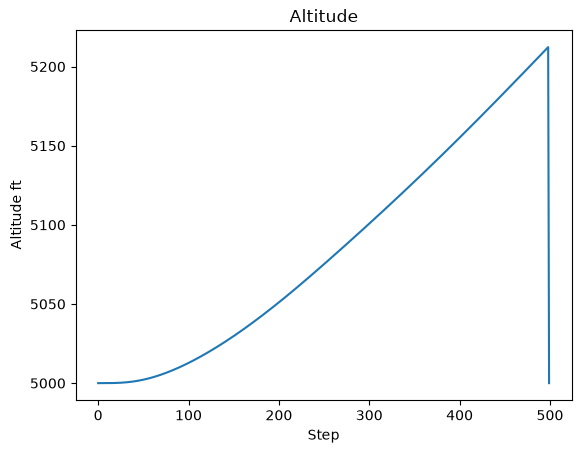

In [32]:
import matplotlib.pyplot as plt

plt.plot(altitudes)
plt.xlabel("Step")
plt.ylabel("Altitude ft")
plt.title("Altitude")
plt.show()

In [35]:
altitudes[-10:]

[np.float32(5207.51),
 np.float32(5208.103),
 np.float32(5208.697),
 np.float32(5209.2905),
 np.float32(5209.885),
 np.float32(5210.4785),
 np.float32(5211.0728),
 np.float32(5211.6665),
 np.float32(5212.2607),
 np.float32(5000.0)]

In [36]:
class FlightEnv(gym.Env):

  def __init__(self):
    super().__init__()

    self.fdm = jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
    self.fdm.load_model("c172p")

    self.action_space = gym.spaces.Box(
        low=-1, # elevator, aileron, rudder, throttle
        high=1,
        shape=(4,),
        dtype=np.float32
    )

    self.observation_space = gym.spaces.Box(
        low=-np.inf,
        high=np.inf,
        shape=(6,), # altitude, velocity, pitch, roll, yaw, vertical_speed
        dtype=np.float32
    )

    self.step_count = 0
    self.max_steps = 500

  # reset episode başı için başlangıç durumlarını getirmek için
  def reset(self, seed=None, options=None):
    super().reset(seed=seed)

    self.step_count = 0

    self.fdm =jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
    self.fdm.load_model("c172p")

    self.fdm["ic/h-sl-ft"] = 5000 # yükselik
    self.fdm["ic/vc-kts"] = 120 # başlangıç hızı
    self.fdm["ic/terrain-elevation-ft"] = 0 #zemin yüksekliği

    self.fdm.run_ic()

    observation = self._get_observation()
    info = {}

    return observation, info

  # step(action) ileri götürmek için state'i
  # istediğimiz staleri ppo ya vermek için burası
  def _get_observation(self):

    altitude = self.fdm["position/h-sl-ft"]
    velocity = self.fdm["velocities/vtrue-kts"]
    pitch = self.fdm["attitude/theta-rad"]
    roll = self.fdm["attitude/phi-rad"]
    yaw = self.fdm["attitude/psi-rad"]
    vertical_speed = self.fdm["velocities/v-down-fps"]

    observation = np.array([
        altitude,
        velocity,
        pitch,
        roll,
        yaw,
        vertical_speed
    ], dtype=np.float32)

    return observation

  def step(self, action):
    elevator = action[0]
    aileron = action[1]
    rudder = action[2]
    throttle = (action[3] + 1) / 2

    self.fdm["fcs/elevator-cmd-norm"] = float(elevator)
    self.fdm["fcs/aileron-cdm-norm"] = float(aileron)
    self.fdm["fcs/rudder-cmd-norm"] = float(rudder)
    self.fdm["fcs/throtlle-cmd-norm"] = float(throttle)

    # bir adım ileri götürmek için
    self.fdm.run()

    self.step_count += 1

    observation = self._get_observation()

    target_altitude = 5000
    target_velocity = 120
    target_pitch = 0.0
    target_roll = 0.0

    altitude = self.fdm["position/h-sl-ft"]
    velocity = self.fdm["velocities/vtrue-kts"]
    pitch = self.fdm["attitude/theta-rad"]
    roll = self.fdm["attitude/phi-rad"]

    altitude_error = abs(altitude - target_altitude)
    velocity_error = abs(velocity - target_velocity)
    pitch_error = abs(pitch - target_pitch)
    roll_error = abs(roll - target_roll)

    reward = (
        -0.001 * altitude_error
        -0.01 * velocity_error
        -1.0 * pitch_error
        -1.0 * roll_error
    )

    

    terminated = False
    truncated = self.step_count >= self.max_steps

    info = {}

    return observation, reward, terminated, truncated, info


In [38]:
vec_env.close()
vec_env = DummyVecEnv([lambda: FlightEnv()])
vec_env = VecNormalize(
    vec_env,
    norm_obs=True,
    norm_reward=True
)

model = PPO(
    "MlpPolicy",
    vec_env,
    verbose=1
)





     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [51]:
model.learn(total_timesteps=100000)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [42]:
obs = vec_env.reset()

total_reward = 0

for i in range(500):

    action, _ = model.predict(observation=obs, deterministic=True)

    obs, reward, done, info = vec_env.step(action)

    total_reward += reward[0]

    if done[0]:
        break

print("uçuş adımı: ", i + 1)
print("toplam normalize reward: ", total_reward)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [52]:
obs = vec_env.reset()

altitudes = []
velocities = []
pitches = []
rolls = []

for i in range(500):

    action, _ = model.predict(observation=obs, deterministic=True)

    obs, reward, done, info = vec_env.step(action)

    real_obs = vec_env.get_original_obs()[0]
    total_reward += reward[0]

    altitudes.append(real_obs[0])
    velocities.append(real_obs[1])
    pitches.append(real_obs[2])
    rolls.append(real_obs[3])

    if done[0]:
        break

print("uçuş adımı: ", i + 1)
print("başlangıç altitude", altitudes[0])
print("son altitude: ", altitudes[498])
print("başlangıç velocity: ", velocities[1])
print("son velocity: ", velocities[498])
print("son pitch: ", pitches[498])
print("son roll: ", rolls[498])



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

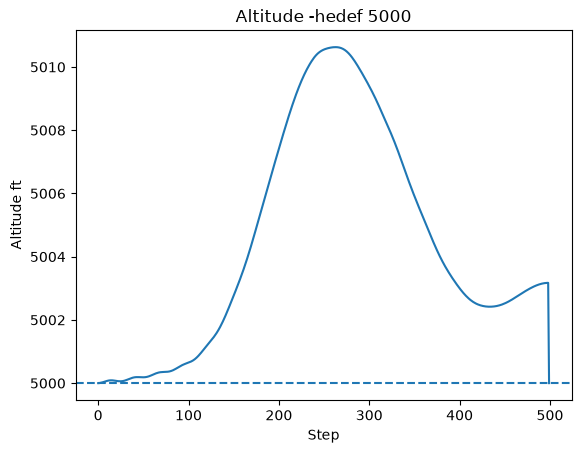

In [53]:
plt.plot(altitudes)
plt.axhline(5000, linestyle="--")
plt.xlabel("Step")
plt.ylabel("Altitude ft")
plt.title("Altitude -hedef 5000")
plt.show()

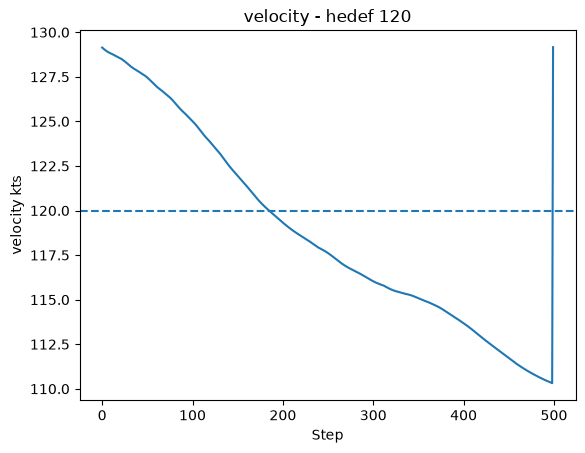

In [ ]:
plt.plot(velocities)
plt.axhline(120, linestyle="--")
plt.xlabel("Step")
plt.ylabel("velocity kts")
plt.title("velocity - hedef 120")
plt.show()

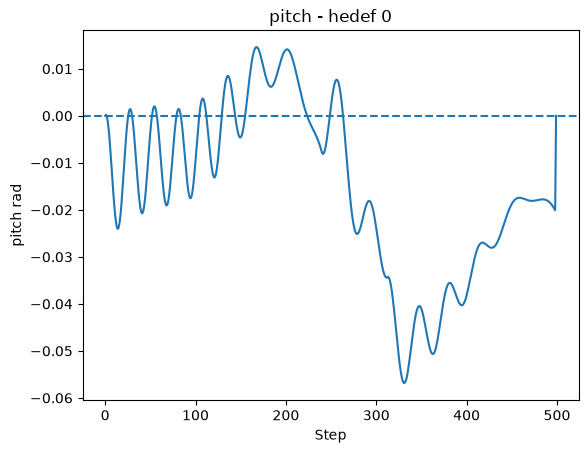

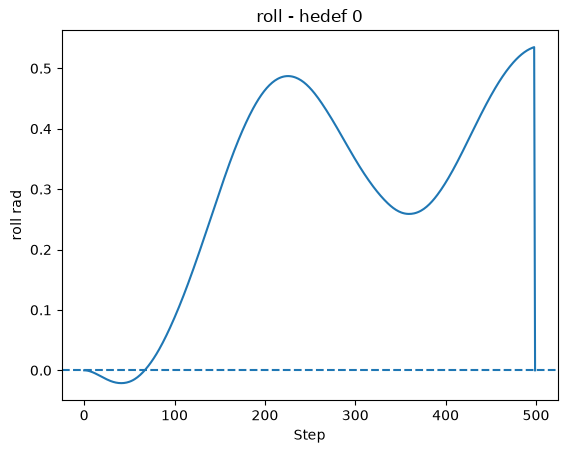

In [56]:
plt.plot(pitches)
plt.axhline(0, linestyle="--")
plt.xlabel("Step")
plt.ylabel("pitch rad")
plt.title("pitch - hedef 0")
plt.show()

plt.plot(rolls)
plt.axhline(0, linestyle="--")
plt.xlabel("Step")
plt.ylabel("roll rad")
plt.title("roll - hedef 0")
plt.show()

In [58]:
model.learn(
    total_timesteps=100000, 
    reset_num_timesteps=False)




     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [59]:
obs = vec_env.reset()

altitudes = []
velocities = []
pitches = []
rolls = []
rewars = []

for i in range(500):

    action, _ = model.predict(observation=obs, deterministic=True)

    obs, reward, done, info = vec_env.step(action)

    real_obs = vec_env.get_original_obs()[0]
    total_reward += reward[0]

    altitudes.append(real_obs[0])
    velocities.append(real_obs[1])
    pitches.append(real_obs[2])
    rolls.append(real_obs[3])
    rewards.append(reward[0])

    if done[0]:
        break

print("uçuş adımı: ", i + 1)
print("başlangıç altitude", altitudes[0])
print("son altitude: ", altitudes[498])
print("başlangıç velocity: ", velocities[1])
print("son velocity: ", velocities[498])
print("son pitch: ", pitches[498])
print("son roll: ", rolls[498])
print("ortalama normalize reward: ", sum(rewards) / len(rewards))



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

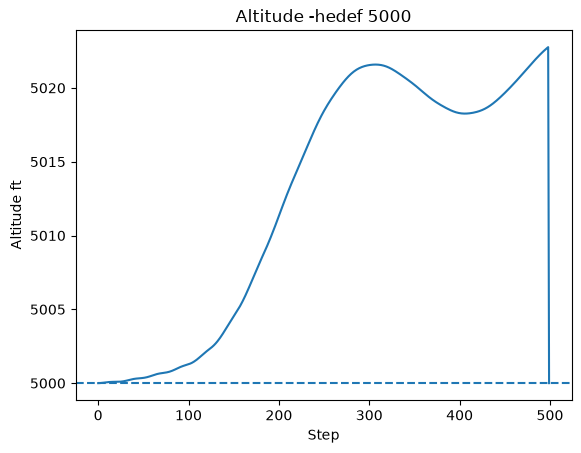

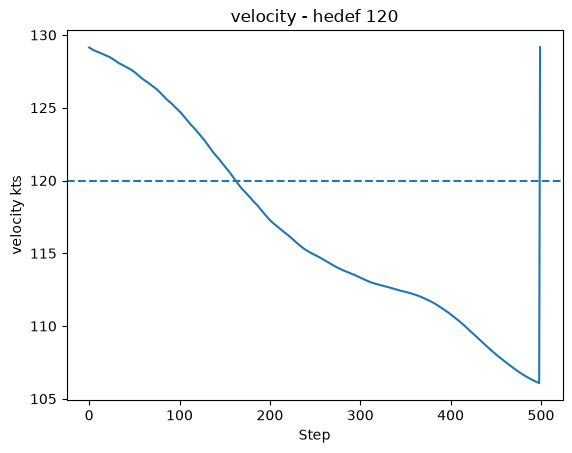

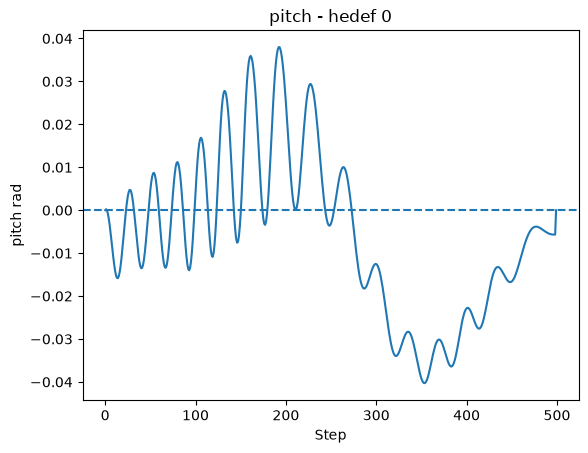

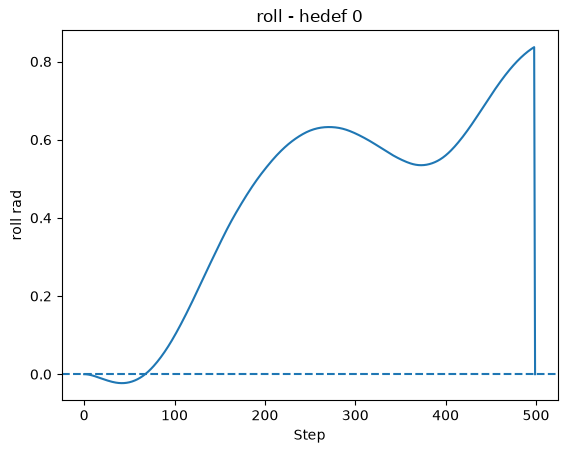

In [60]:
plt.plot(altitudes)
plt.axhline(5000, linestyle="--")
plt.xlabel("Step")
plt.ylabel("Altitude ft")
plt.title("Altitude -hedef 5000")
plt.show()

plt.plot(velocities)
plt.axhline(120, linestyle="--")
plt.xlabel("Step")
plt.ylabel("velocity kts")
plt.title("velocity - hedef 120")
plt.show()

plt.plot(pitches)
plt.axhline(0, linestyle="--")
plt.xlabel("Step")
plt.ylabel("pitch rad")
plt.title("pitch - hedef 0")
plt.show()

plt.plot(rolls)
plt.axhline(0, linestyle="--")
plt.xlabel("Step")
plt.ylabel("roll rad")
plt.title("roll - hedef 0")
plt.show()

In [64]:
test_env = FlightEnv()
obs, info = test_env.reset()

action = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)

obs, reward, termianted, truncated, info = test_env.step(action)

print("observation: ", obs)
print("reward: ", reward)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [65]:
# ENV İçin test modu

vec_env.training = False
vec_env.norm_reward = False

In [66]:
obs = vec_env.reset()

total_reward = 0

for i in range(500):

    action, _ = model.predict(observation=obs, deterministic=True)

    obs, reward, done, info = vec_env.step(action)

    
    total_reward += reward


    if done[0]:
        break

print("uçuş adımı: ", i + 1)
print("reward: ", total_reward)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   